In [1]:
import pandas as pd
df = pd.read_csv("dp_lms_student_analytics_dataset.csv")
print(df)
df.head()


     StudentID    StudentName  Gender  Age       City             Course  \
0            1   Bikash Karki    Male   18    Pokhara     Advanced Excel   
1            2      Nabin Rai    Male   24     Butwal         MERN Stack   
2            3   Asmita Thapa  Female   24    Pokhara  Digital Marketing   
3            4   Nabin Basnet  Female   20    Itahari  Python with AI/ML   
4            5    Sita Basnet  Female   24   Janakpur     Advanced Excel   
..         ...            ...     ...  ...        ...                ...   
495        496  Prakash Karki    Male   30  Kathmandu  Python with AI/ML   
496        497    Gita Basnet    Male   18    Pokhara              UI/UX   
497        498      Rohan Rai    Male   24  Kathmandu         MERN Stack   
498        499   Nabin Basnet    Male   20  Kathmandu              UI/UX   
499        500    Aarav Karki    Male   28     Butwal     Advanced Excel   

           Instructor EnrollmentDate   Batch  CourseFee  ...  \
0    Sanjeev Shrestha  

In [3]:
print("Rows and Columns:", df.shape)
print(df.columns)
df.info()
df.describe()

Rows and Columns: (500, 21)
Index(['StudentID', 'StudentName', 'Gender', 'Age', 'City', 'Course',
       'Instructor', 'EnrollmentDate', 'Batch', 'CourseFee', 'PaymentMethod',
       'AttendancePercentage', 'AssignmentScore', 'QuizScore', 'FinalScore',
       'CourseProgress', 'StudyHoursPerWeek', 'LoginCount',
       'CertificateIssued', 'StudentStatus', 'Revenue'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudentID             500 non-null    int64
 1   StudentName           500 non-null    str  
 2   Gender                500 non-null    str  
 3   Age                   500 non-null    int64
 4   City                  500 non-null    str  
 5   Course                500 non-null    str  
 6   Instructor            500 non-null    str  
 7   EnrollmentDate        500 non-null    str  
 8   Batch                 

,StudentID,Age,CourseFee,AttendancePercentage,AssignmentScore,QuizScore,FinalScore,CourseProgress,StudyHoursPerWeek,LoginCount,Revenue
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,26.306000,4902.000000,77.664000,74.432000,71.070000,73.980000,77.204000,11.606000,61.372000,4902.000000
std,144.481833,5.090795,1339.022765,12.105875,14.199317,15.740414,8.554177,12.460213,5.403439,33.058544,1339.022765
min,1.000000,18.000000,3000.000000,42.000000,33.000000,21.000000,43.000000,47.000000,2.000000,5.000000,3000.000000
25%,125.750000,22.000000,4000.000000,69.000000,64.000000,60.000000,68.000000,68.750000,7.000000,35.000000,4000.000000
50%,250.500000,26.000000,4500.000000,77.000000,74.000000,71.000000,74.000000,77.000000,12.000000,60.500000,4500.000000
75%,375.250000,31.000000,6500.000000,87.000000,85.000000,82.250000,80.000000,86.000000,16.000000,89.000000,6500.000000
max,500.000000,35.000000,7000.000000,100.000000,100.000000,100.000000,97.000000,100.000000,20.000000,120.000000,7000.000000


In [4]:
df["EnrollmentDate"] = pd.to_datetime(df["EnrollmentDate"])

df["Month"] = df["EnrollmentDate"].dt.to_period("M").astype(str)

df.head()

,StudentID,StudentName,Gender,Age,City,Course,Instructor,EnrollmentDate,Batch,CourseFee,...,AssignmentScore,QuizScore,FinalScore,CourseProgress,StudyHoursPerWeek,LoginCount,CertificateIssued,StudentStatus,Revenue,Month
0,1,Bikash Karki,Male,18,Pokhara,Advanced Excel,Sanjeev Shrestha,2025-03-31,AI-02,3000,...,90,72,81,100,19,30,Yes,Inactive,3000,2025-03
1,2,Nabin Rai,Male,24,Butwal,MERN Stack,Manish Basnet,2026-03-09,AI-01,7000,...,63,76,69,79,5,50,No,Inactive,7000,2026-03
2,3,Asmita Thapa,Female,24,Pokhara,Digital Marketing,Manish Basnet,2025-10-28,AI-02,4000,...,79,64,74,69,4,114,No,Active,4000,2025-10
3,4,Nabin Basnet,Female,20,Itahari,Python with AI/ML,Sanjeev Shrestha,2026-01-15,AI-02,5000,...,62,84,75,74,14,39,No,Active,5000,2026-01
4,5,Sita Basnet,Female,24,Janakpur,Advanced Excel,Samriddha Pathak,2025-10-02,FLT-01,3000,...,97,99,88,70,10,22,No,Active,3000,2025-10


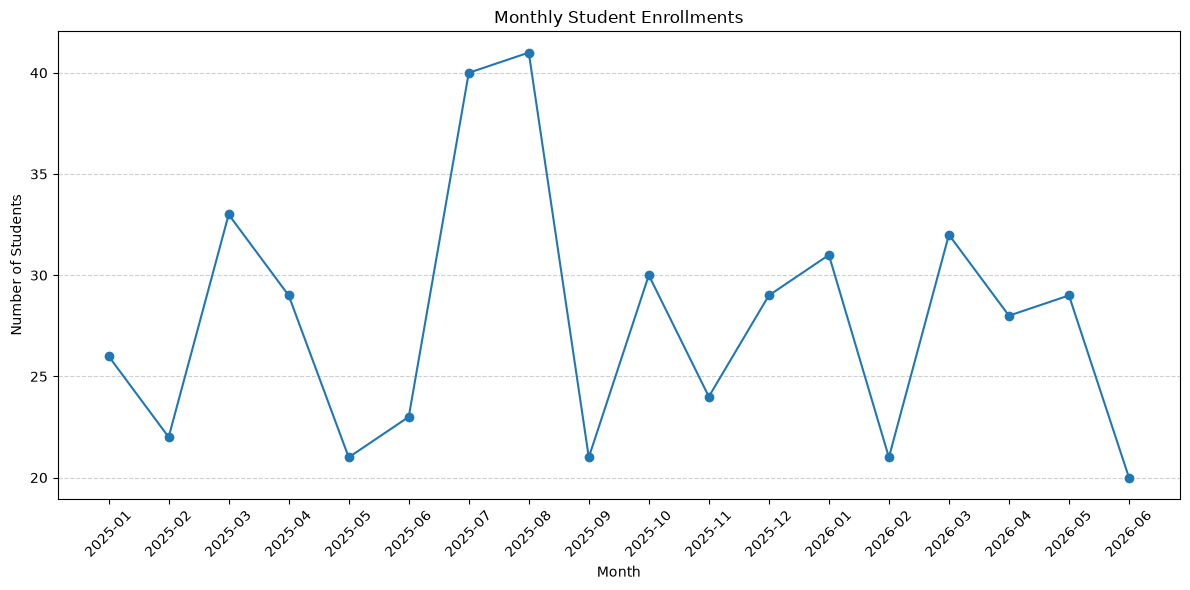

In [5]:
import matplotlib.pyplot as plt
monthly_enrollment = df.groupby("Month")["StudentID"].count()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_enrollment.index,
    monthly_enrollment.values,
    marker="o"
)

plt.title("Monthly Student Enrollments")
plt.xlabel("Month")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

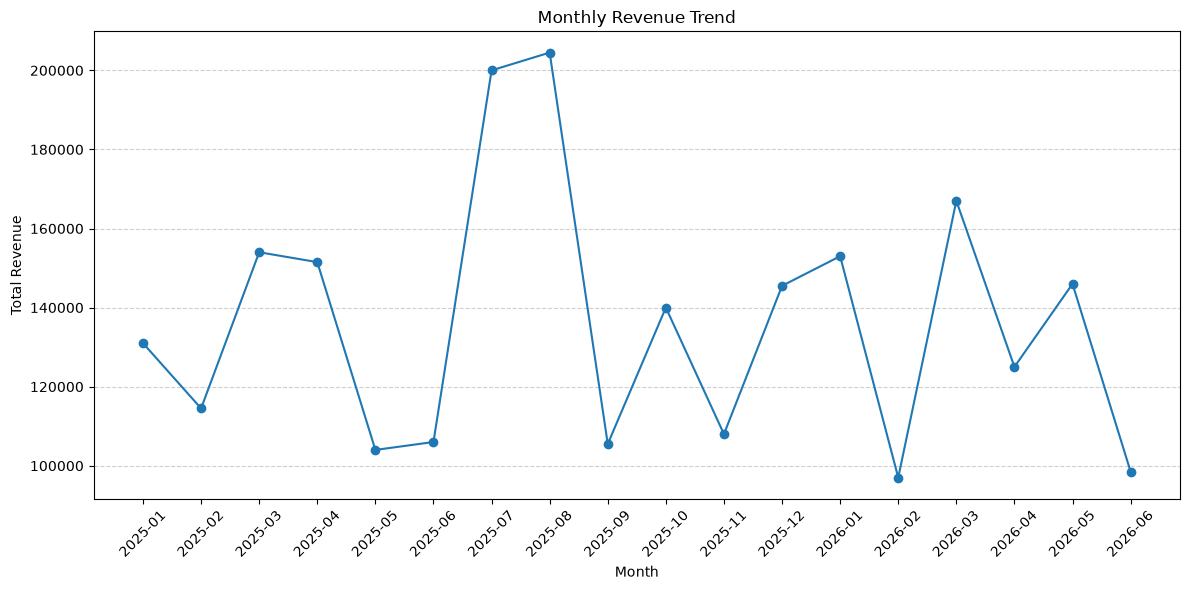

In [6]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

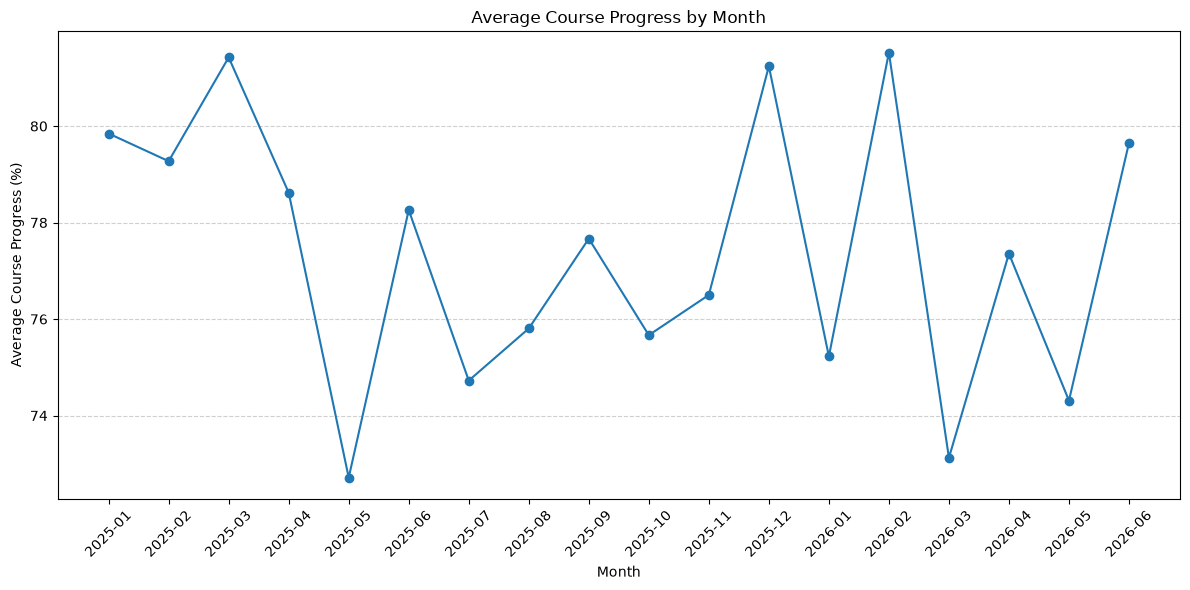

In [7]:
monthly_progress = df.groupby("Month")["CourseProgress"].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_progress.index,
    monthly_progress.values,
    marker="o"
)

plt.title("Average Course Progress by Month")
plt.xlabel("Month")
plt.ylabel("Average Course Progress (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

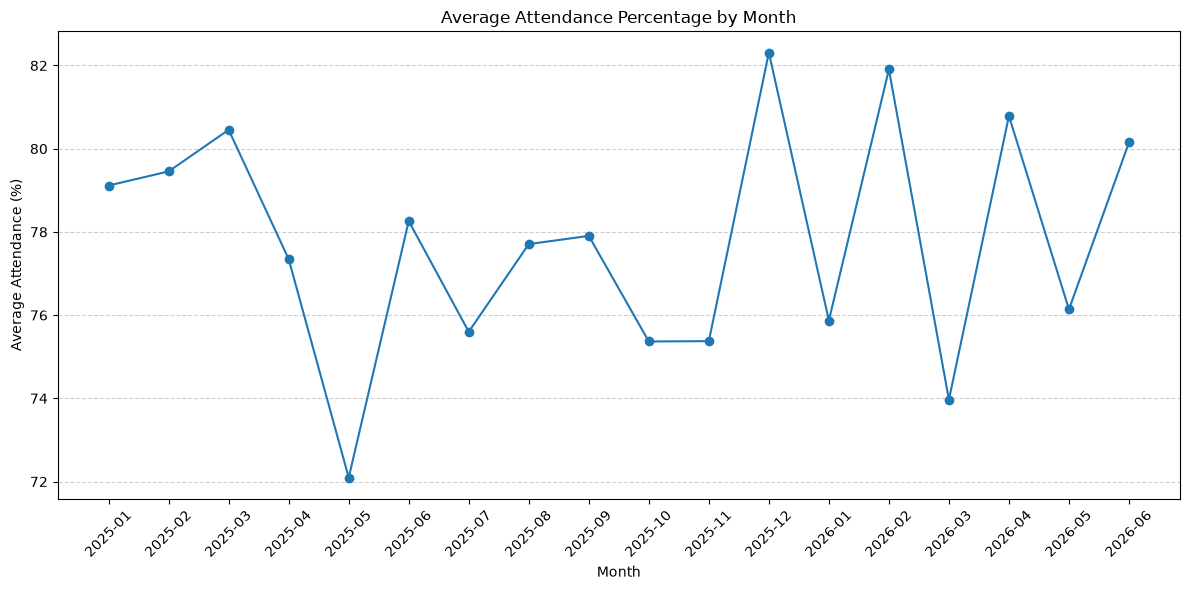

In [8]:
monthly_attendance = df.groupby("Month")["AttendancePercentage"].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_attendance.index,
    monthly_attendance.values,
    marker="o"
)

plt.title("Average Attendance Percentage by Month")
plt.xlabel("Month")
plt.ylabel("Average Attendance (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

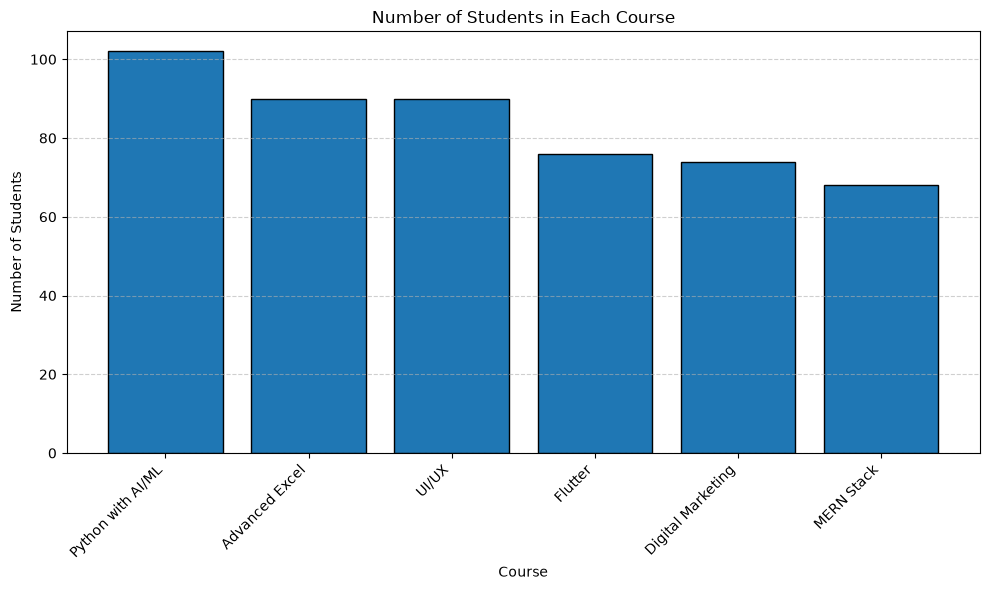

In [9]:
course_students = df["Course"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    course_students.index,
    course_students.values,
    edgecolor="black"
)

plt.title("Number of Students in Each Course")
plt.xlabel("Course")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

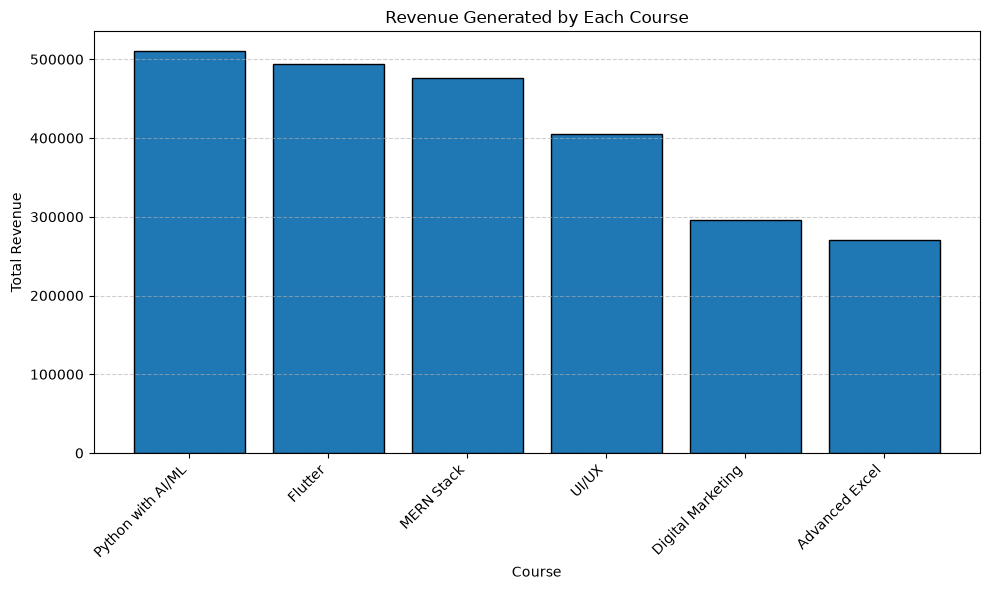

In [10]:
course_revenue = df.groupby("Course")["Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

plt.bar(
    course_revenue.index,
    course_revenue.values,
    edgecolor="black"
)

plt.title("Revenue Generated by Each Course")
plt.xlabel("Course")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

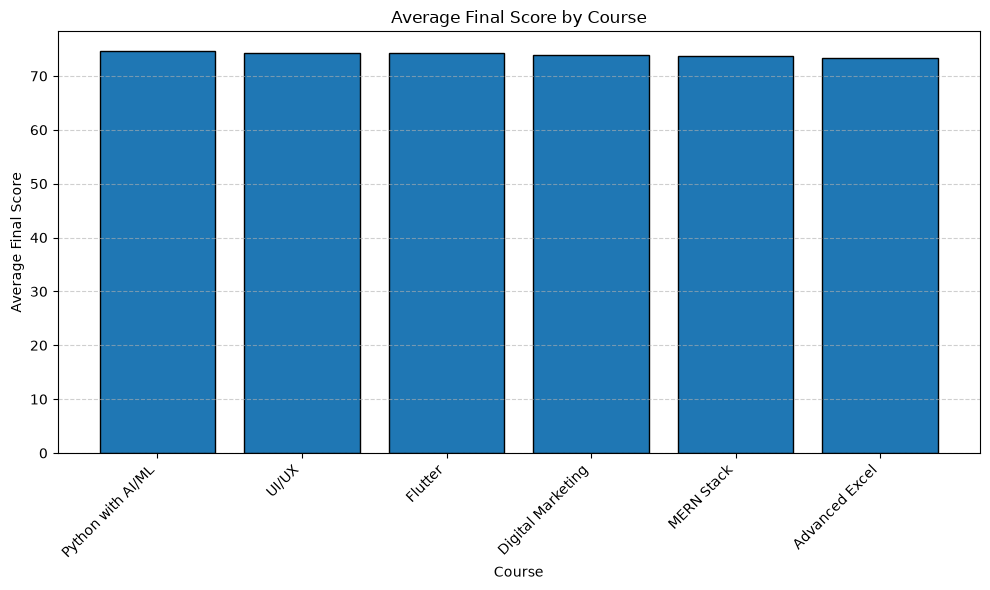

In [11]:
course_final_score = (
    df.groupby("Course")["FinalScore"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    course_final_score.index,
    course_final_score.values,
    edgecolor="black"
)

plt.title("Average Final Score by Course")
plt.xlabel("Course")
plt.ylabel("Average Final Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

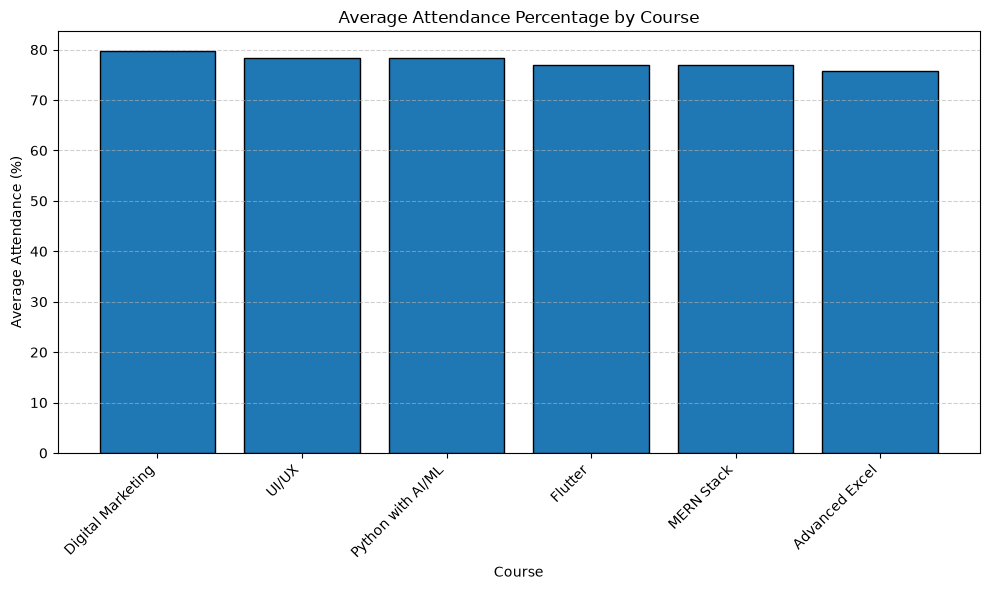

In [12]:
course_attendance = (
    df.groupby("Course")["AttendancePercentage"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    course_attendance.index,
    course_attendance.values,
    edgecolor="black"
)

plt.title("Average Attendance Percentage by Course")
plt.xlabel("Course")
plt.ylabel("Average Attendance (%)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

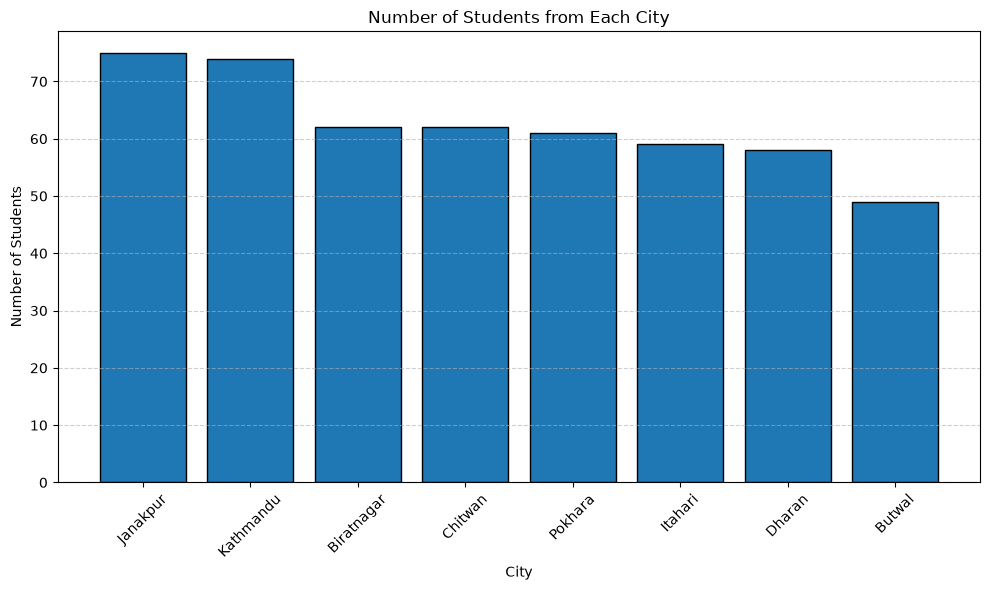

In [13]:
city_students = df["City"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    city_students.index,
    city_students.values,
    edgecolor="black"
)

plt.title("Number of Students from Each City")
plt.xlabel("City")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

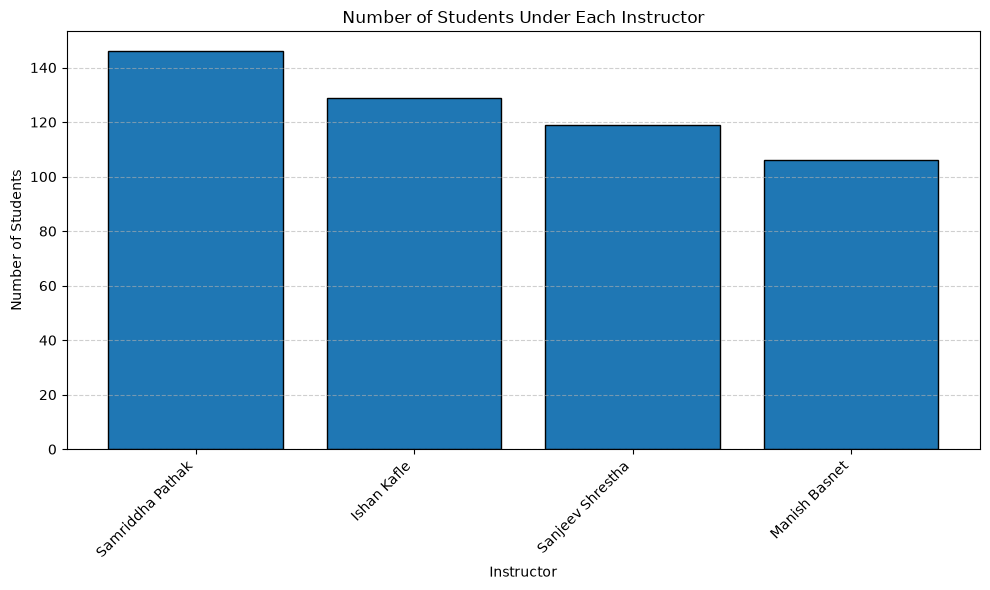

In [14]:
instructor_students = df["Instructor"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    instructor_students.index,
    instructor_students.values,
    edgecolor="black"
)

plt.title("Number of Students Under Each Instructor")
plt.xlabel("Instructor")
plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

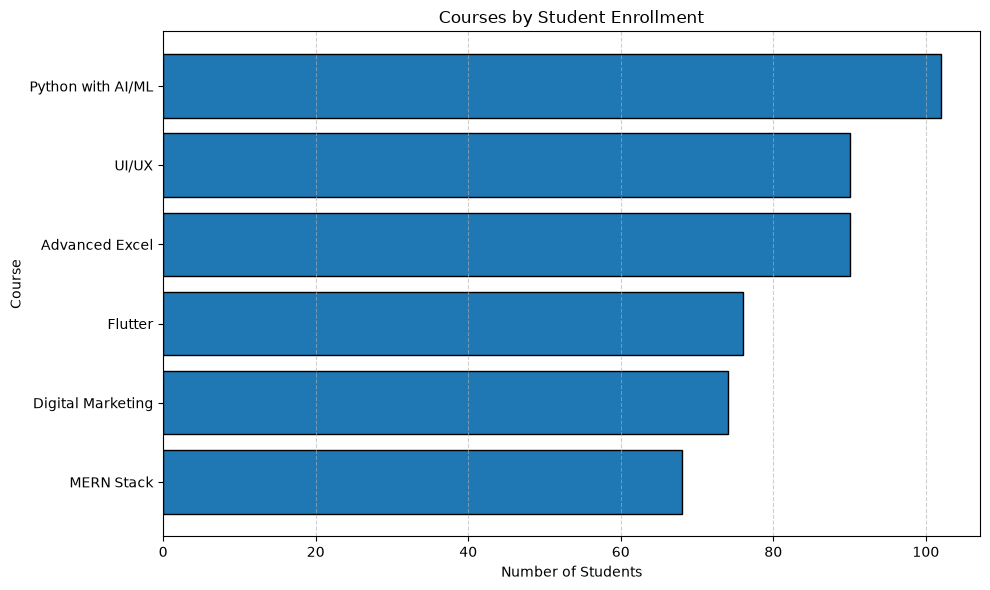

In [15]:
top_courses = df["Course"].value_counts().sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_courses.index,
    top_courses.values,
    edgecolor="black"
)

plt.title("Courses by Student Enrollment")
plt.xlabel("Number of Students")
plt.ylabel("Course")
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

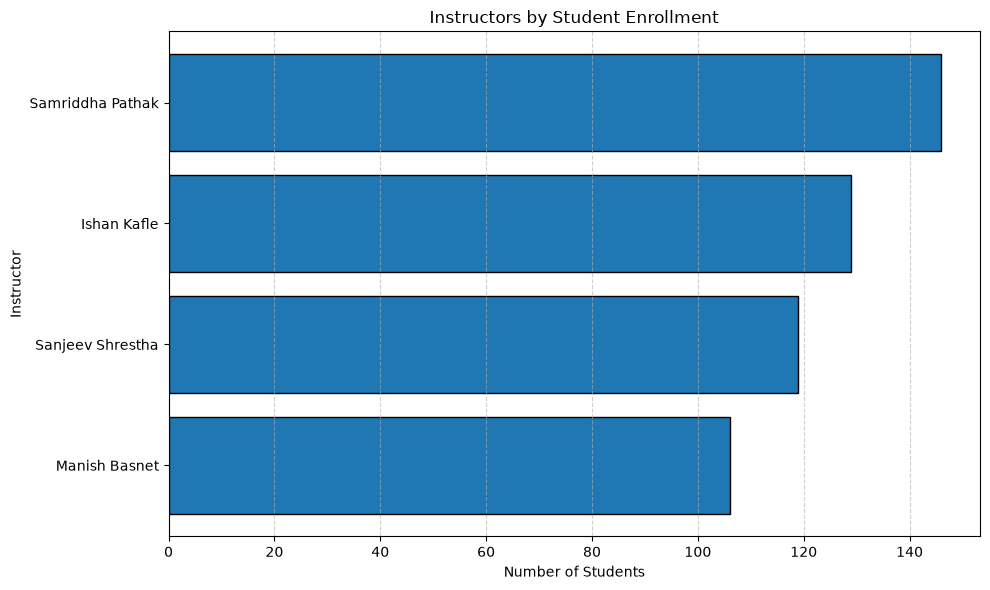

In [16]:
top_instructors = df["Instructor"].value_counts().sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_instructors.index,
    top_instructors.values,
    edgecolor="black"
)

plt.title("Instructors by Student Enrollment")
plt.xlabel("Number of Students")
plt.ylabel("Instructor")
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

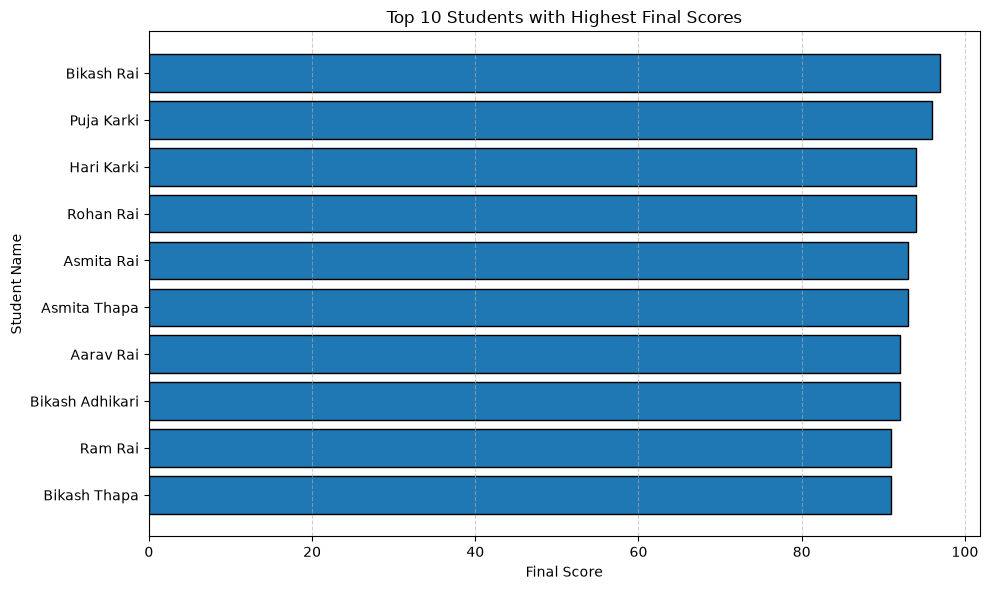

In [17]:
top_students = (
    df.nlargest(10, "FinalScore")
    .sort_values("FinalScore")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_students["StudentName"],
    top_students["FinalScore"],
    edgecolor="black"
)

plt.title("Top 10 Students with Highest Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Student Name")
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

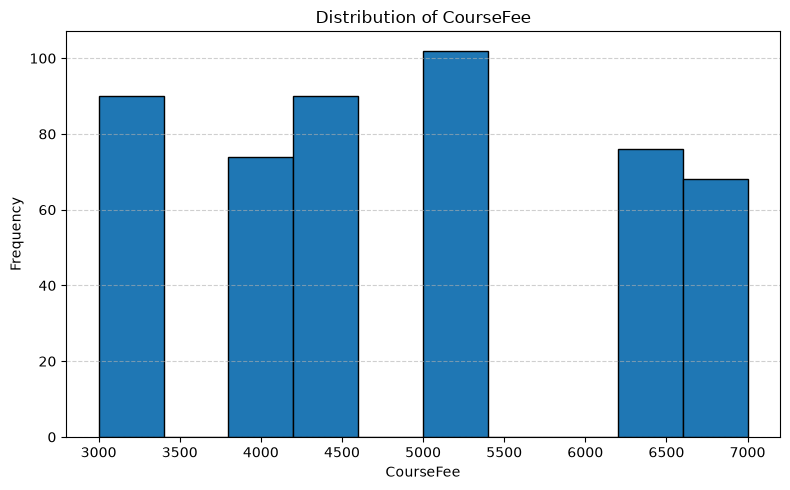

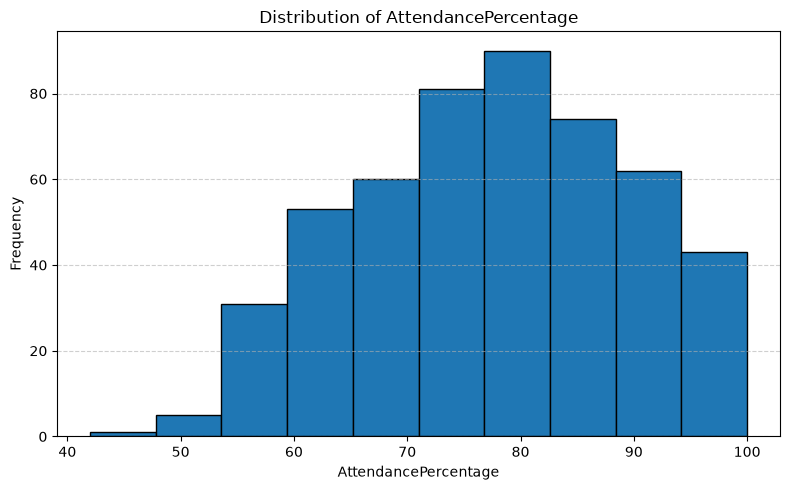

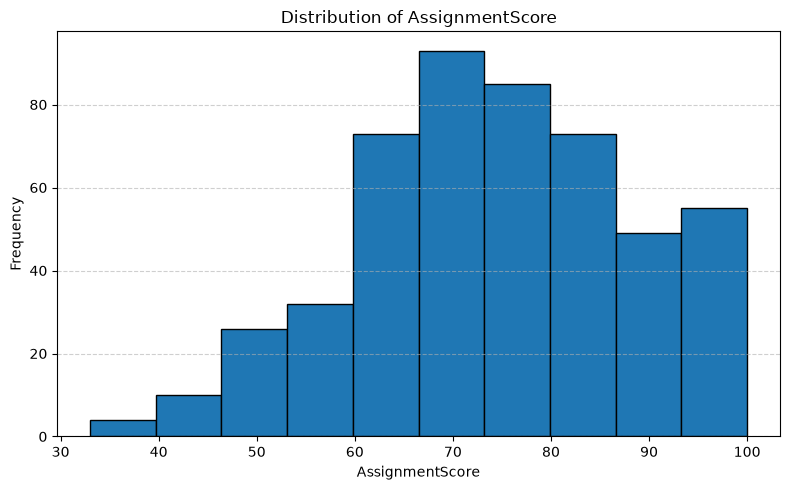

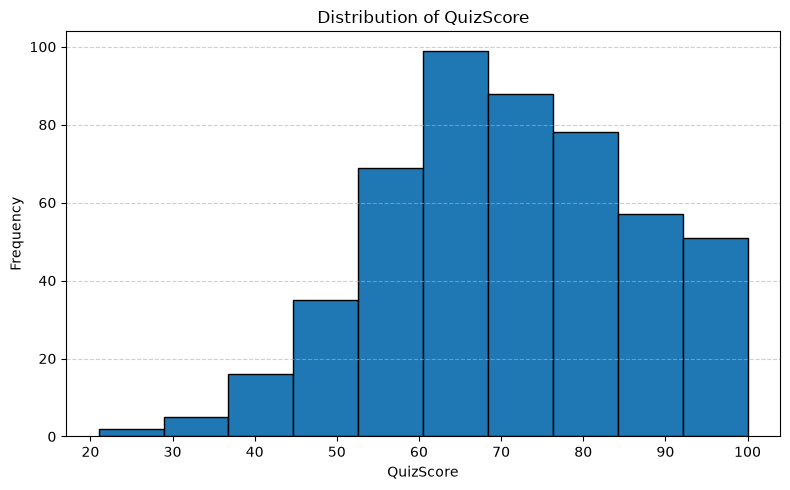

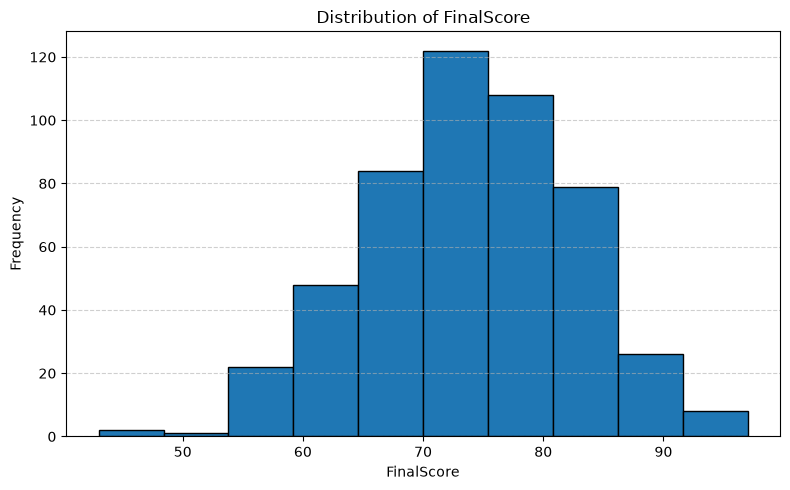

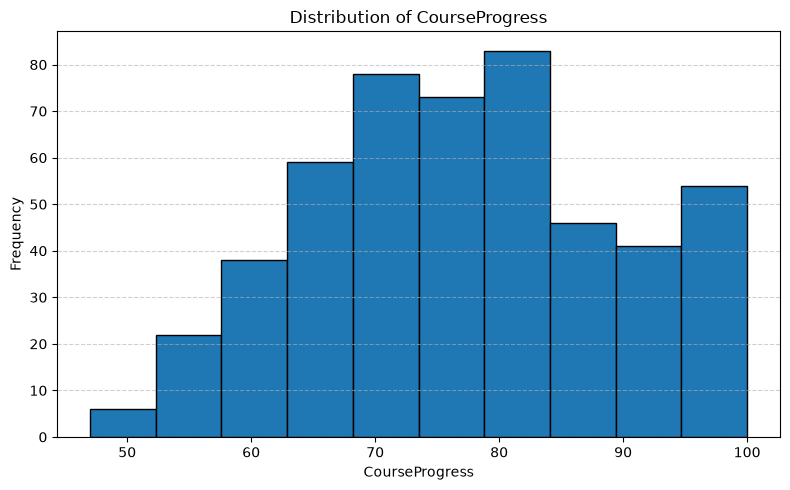

In [18]:
columns = [
    "CourseFee",
    "AttendancePercentage",
    "AssignmentScore",
    "QuizScore",
    "FinalScore",
    "CourseProgress"
]

for column in columns:
    
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        df[column],
        bins=10,
        edgecolor="black"
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

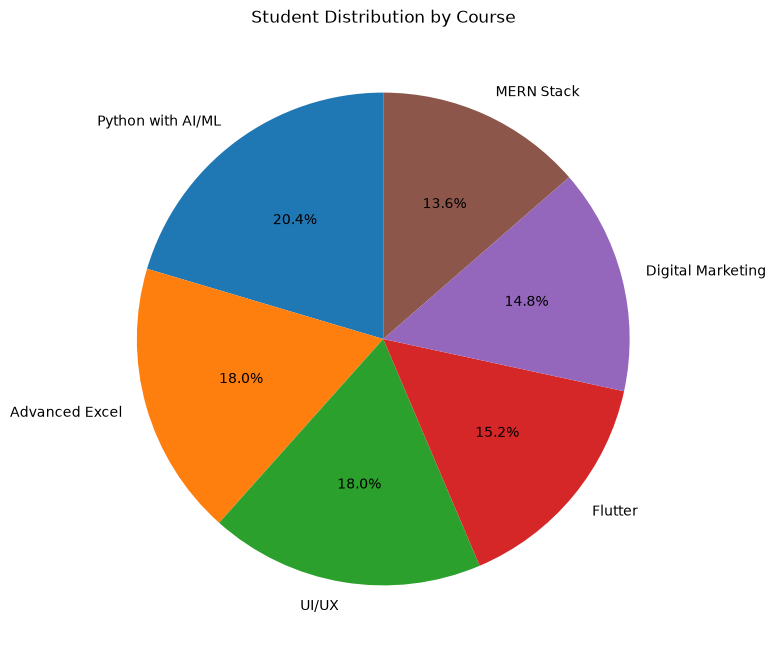

In [19]:
course_distribution = df["Course"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    course_distribution.values,
    labels=course_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Distribution by Course")
plt.show()

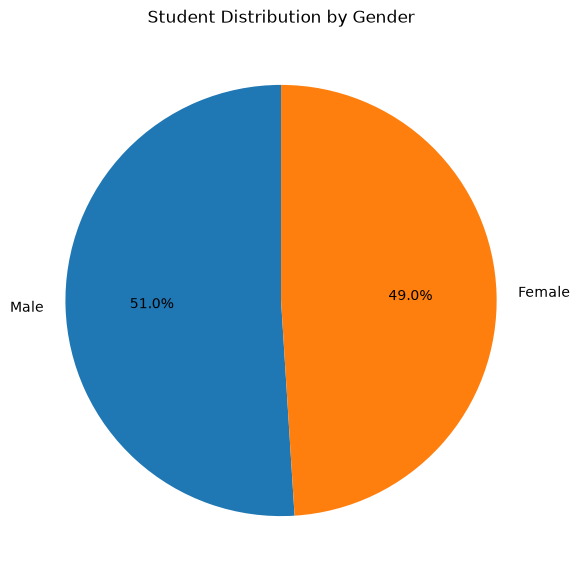

In [20]:
gender_distribution = df["Gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_distribution.values,
    labels=gender_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Distribution by Gender")
plt.show()

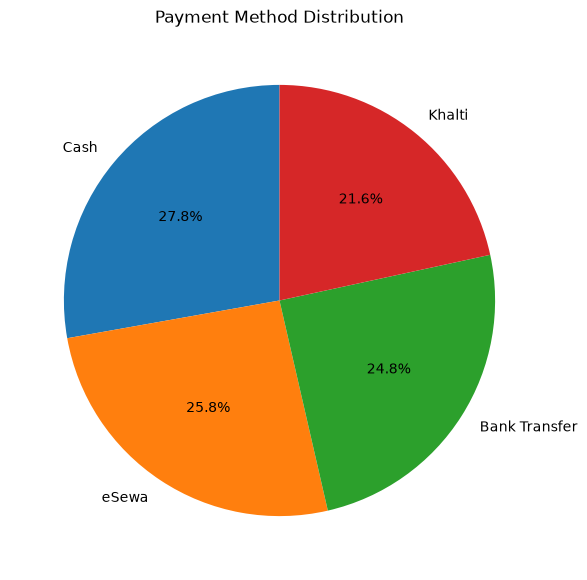

In [21]:
payment_distribution = df["PaymentMethod"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_distribution.values,
    labels=payment_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")
plt.show()

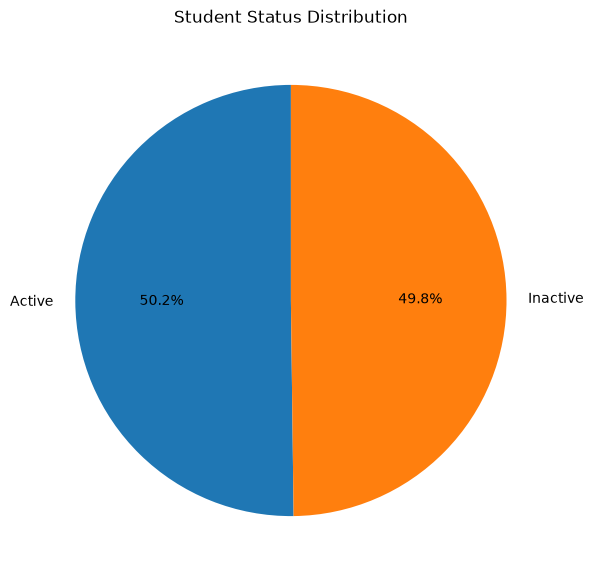

In [22]:
status_distribution = df["StudentStatus"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    status_distribution.values,
    labels=status_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Status Distribution")
plt.show()

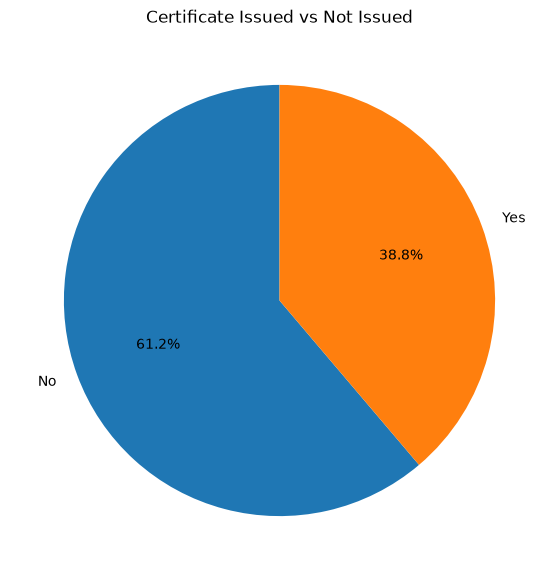

In [23]:
certificate_distribution = df["CertificateIssued"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    certificate_distribution.values,
    labels=certificate_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Certificate Issued vs Not Issued")
plt.show()

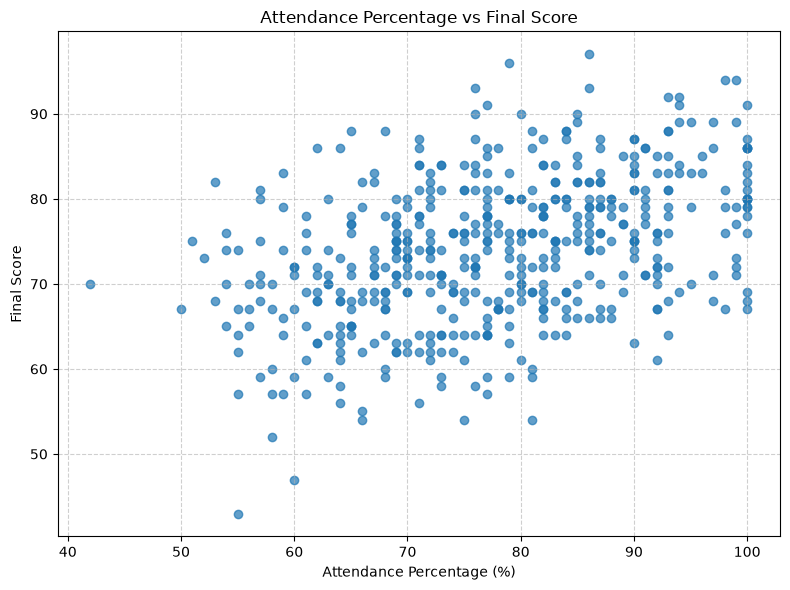

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["AttendancePercentage"],
    df["FinalScore"],
    alpha=0.7
)

plt.title("Attendance Percentage vs Final Score")
plt.xlabel("Attendance Percentage (%)")
plt.ylabel("Final Score")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

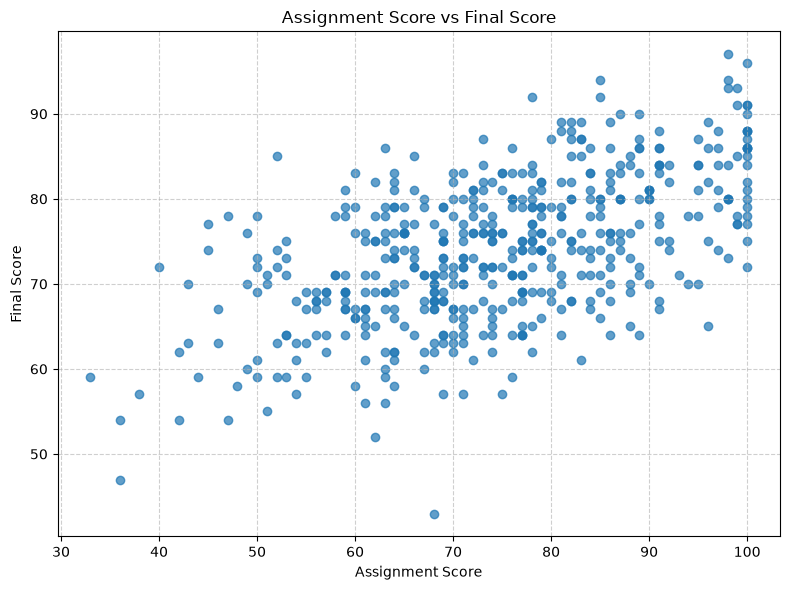

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["AssignmentScore"],
    df["FinalScore"],
    alpha=0.7
)

plt.title("Assignment Score vs Final Score")
plt.xlabel("Assignment Score")
plt.ylabel("Final Score")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

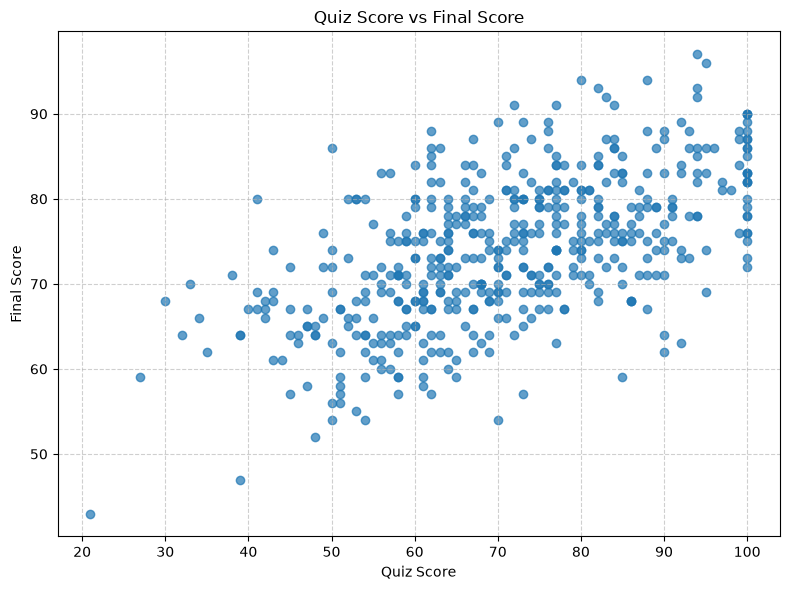

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["QuizScore"],
    df["FinalScore"],
    alpha=0.7
)

plt.title("Quiz Score vs Final Score")
plt.xlabel("Quiz Score")
plt.ylabel("Final Score")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

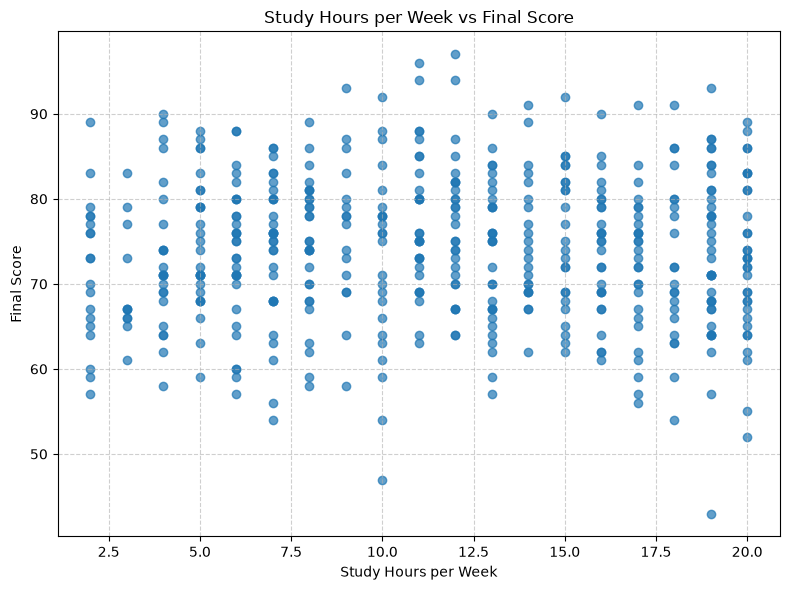

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["StudyHoursPerWeek"],
    df["FinalScore"],
    alpha=0.7
)

plt.title("Study Hours per Week vs Final Score")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

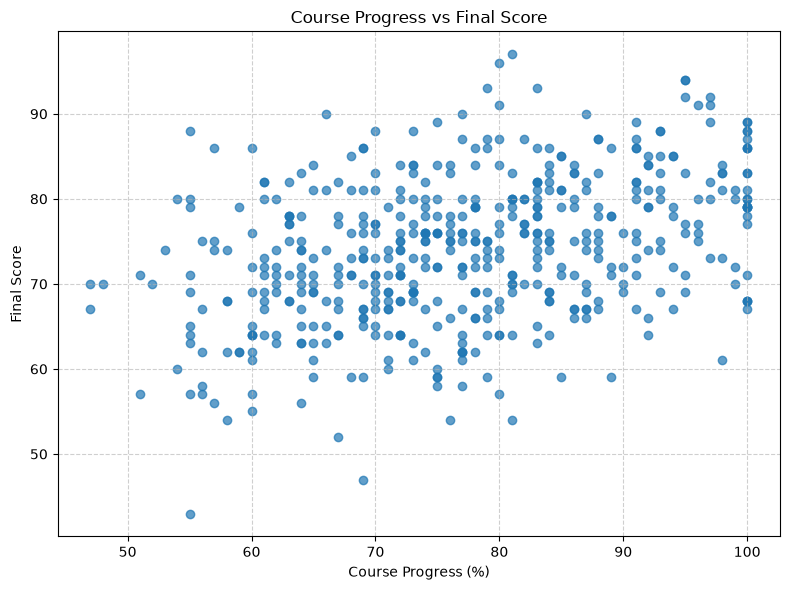

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["CourseProgress"],
    df["FinalScore"],
    alpha=0.7
)

plt.title("Course Progress vs Final Score")
plt.xlabel("Course Progress (%)")
plt.ylabel("Final Score")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

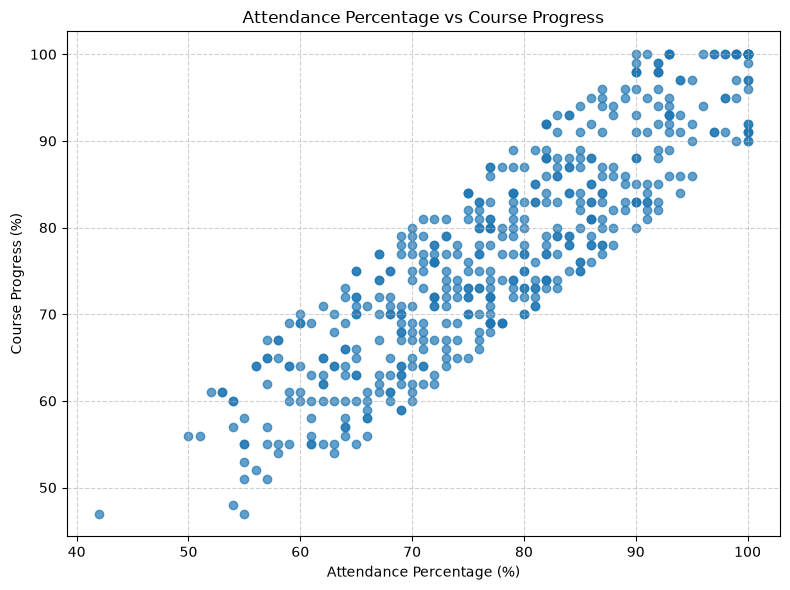

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["AttendancePercentage"],
    df["CourseProgress"],
    alpha=0.7
)

plt.title("Attendance Percentage vs Course Progress")
plt.xlabel("Attendance Percentage (%)")
plt.ylabel("Course Progress (%)")
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [30]:
df["Instructor"].value_counts()


Instructor
Samriddha Pathak    146
Ishan Kafle         129
Sanjeev Shrestha    119
Manish Basnet       106
Name: count, dtype: int64